In [259]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [260]:
df = pd.read_csv('heart.csv')

In [261]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [263]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [264]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

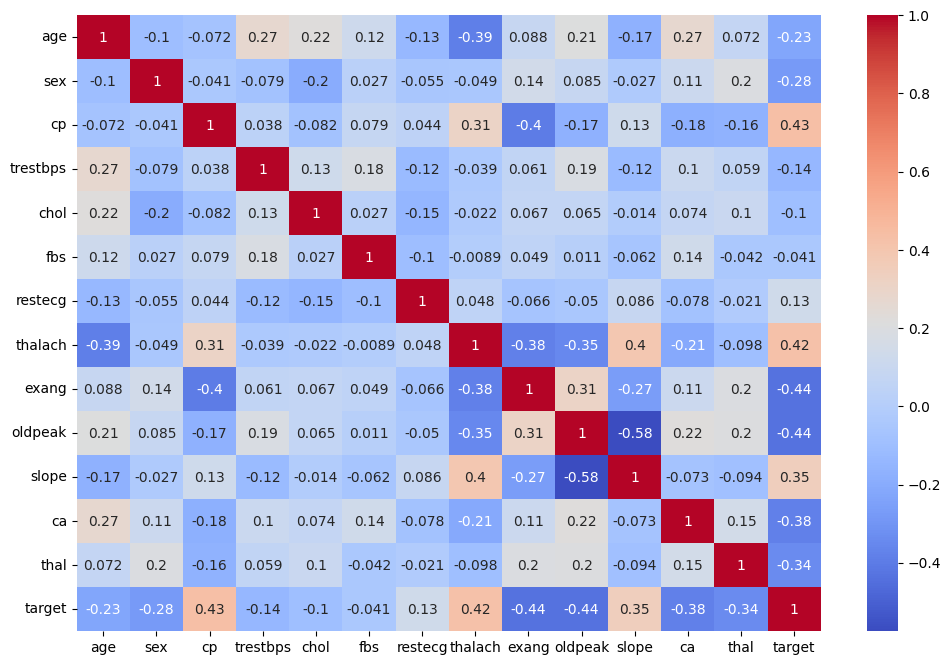

In [265]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm' )
plt.show()

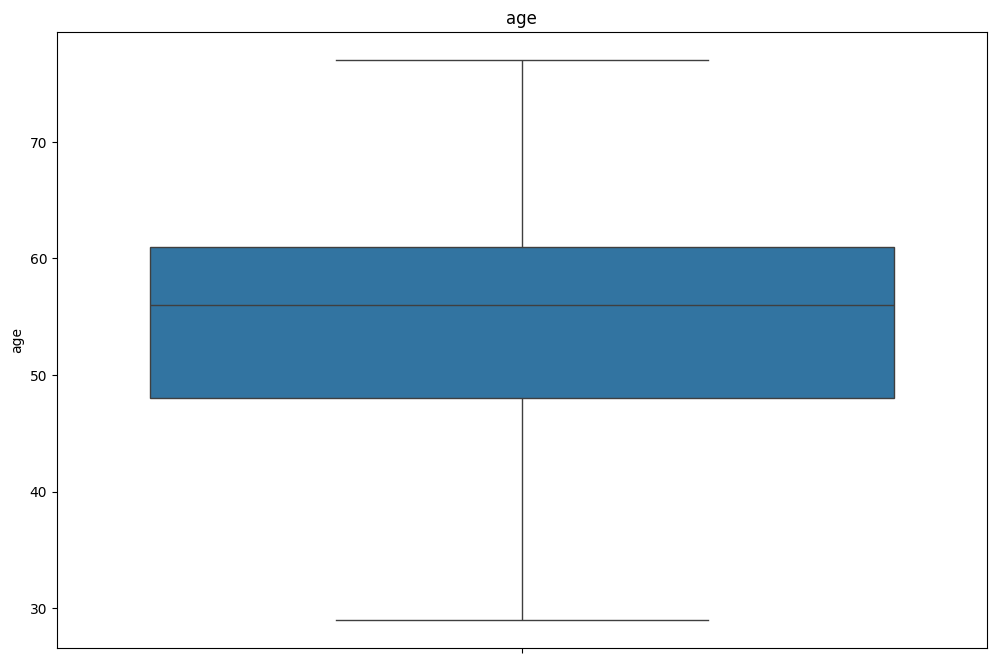

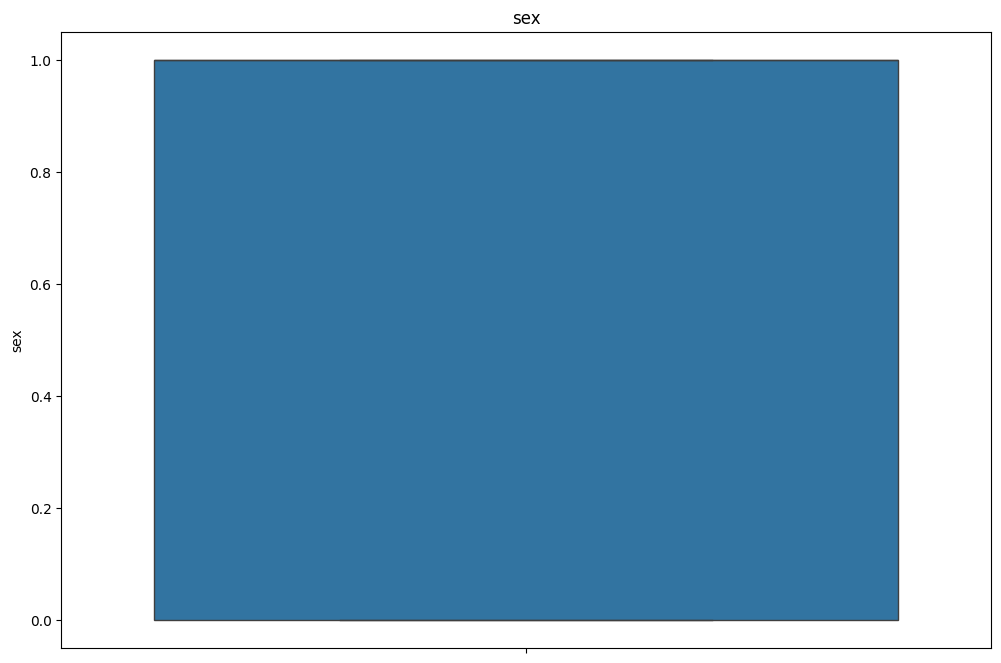

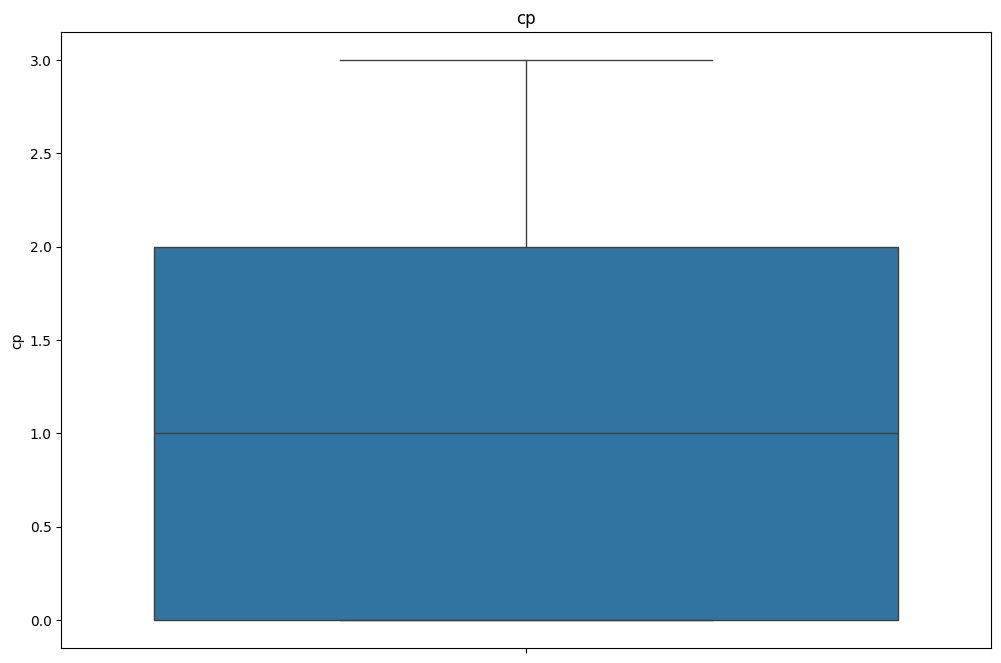

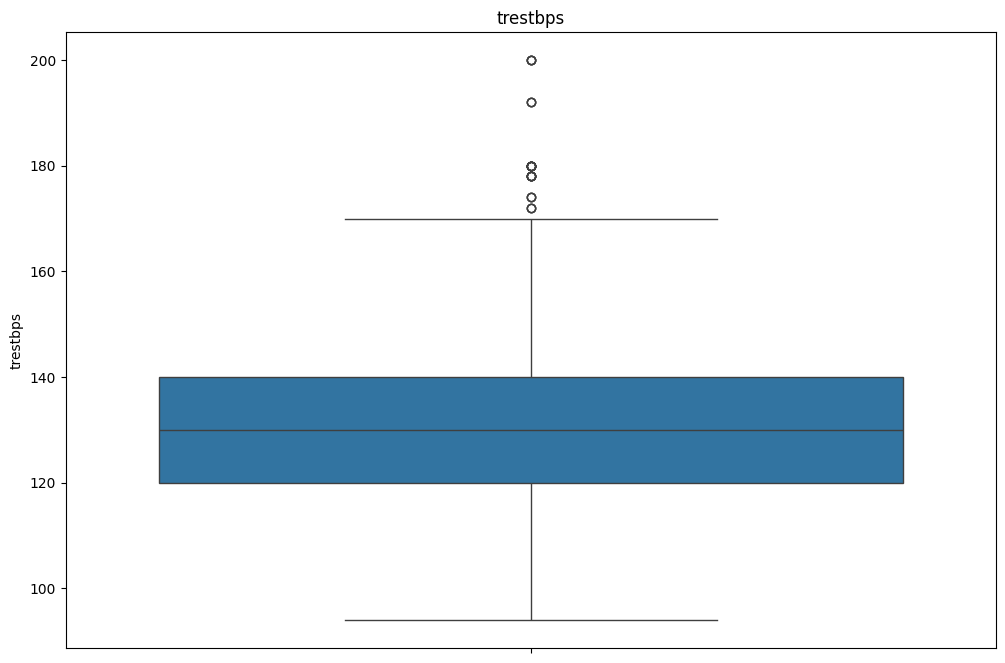

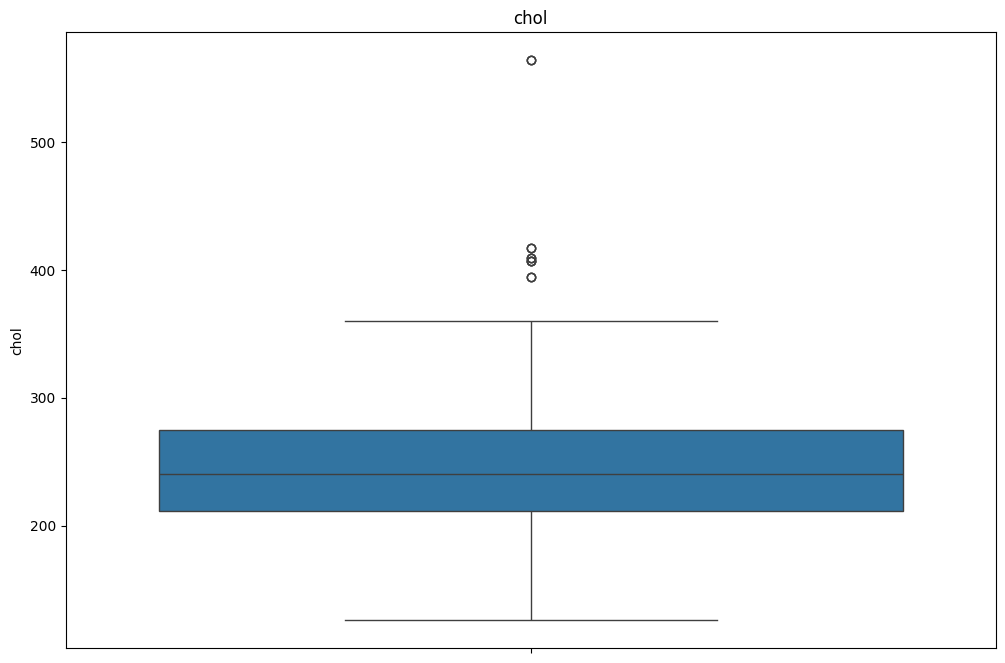

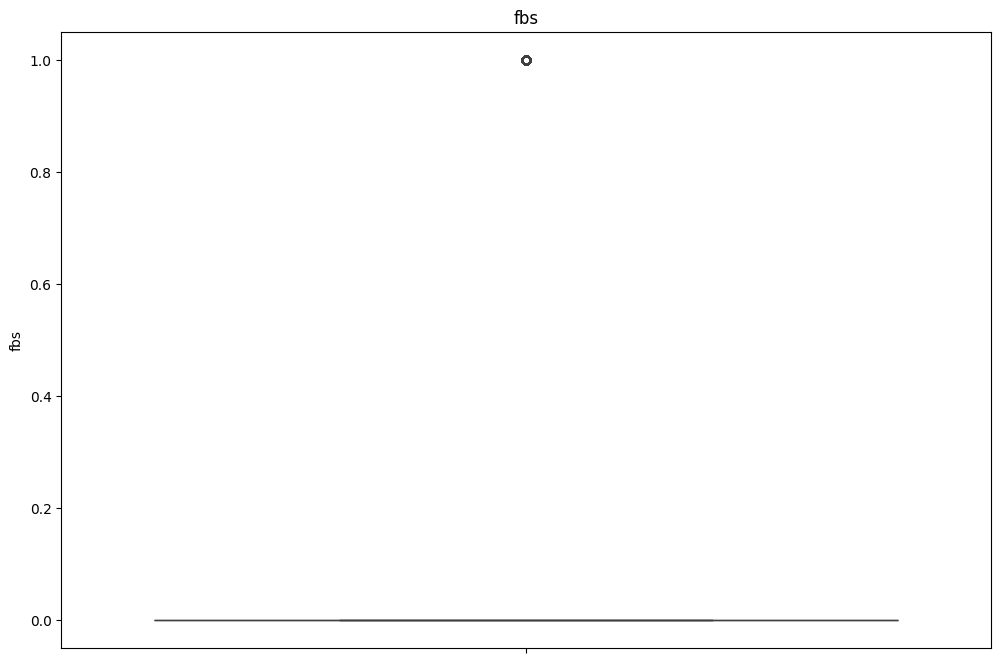

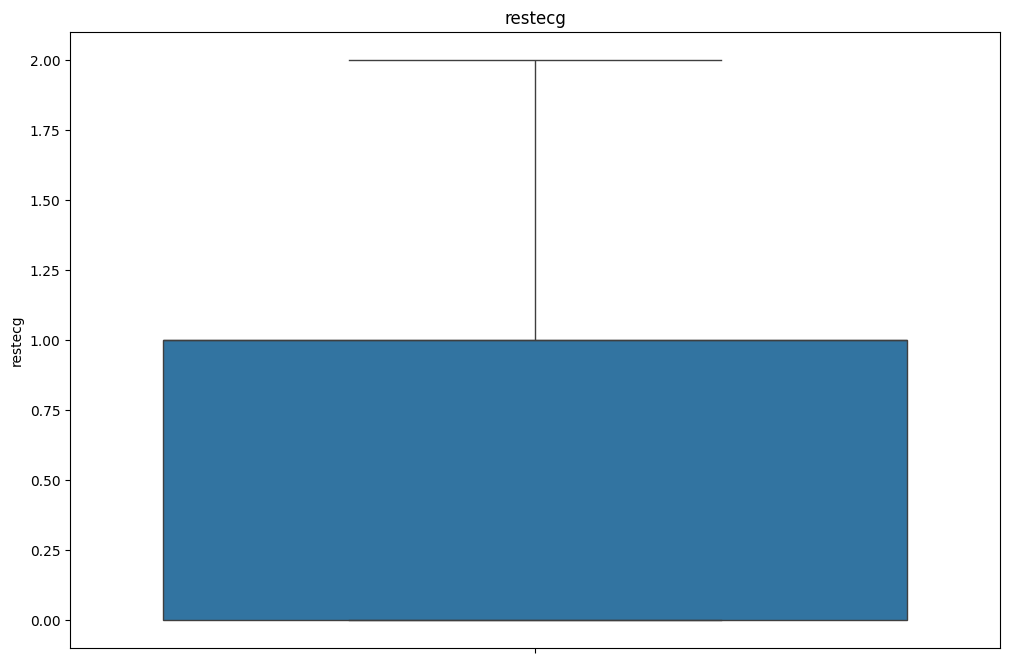

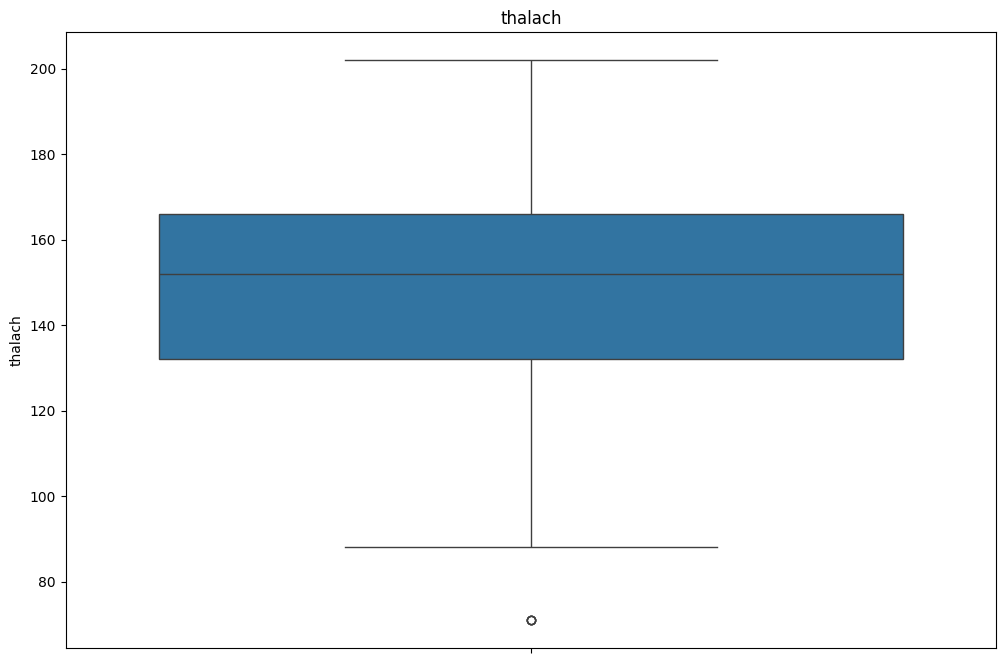

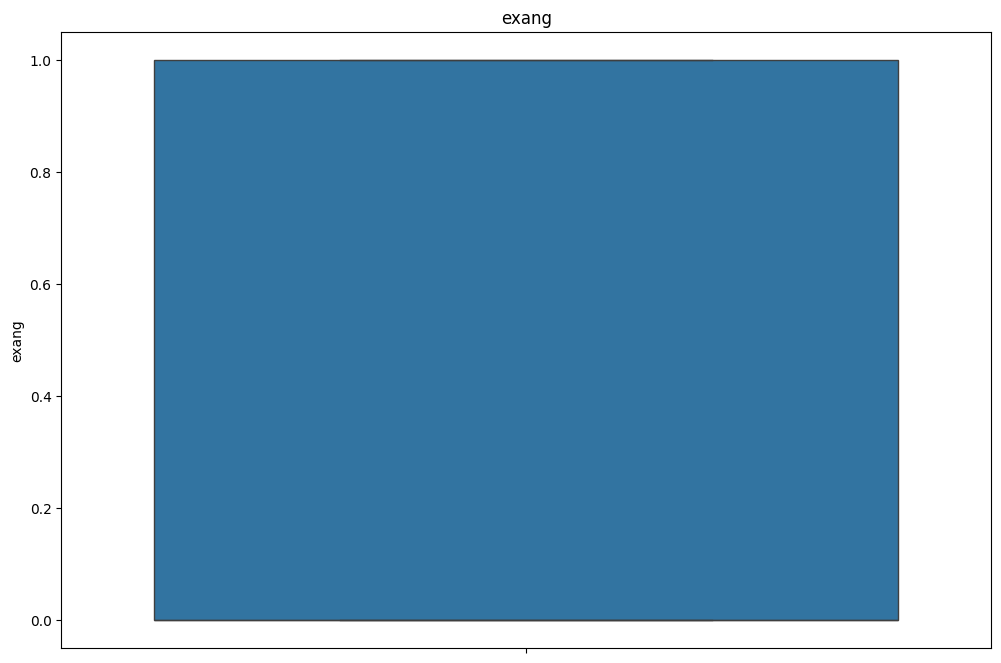

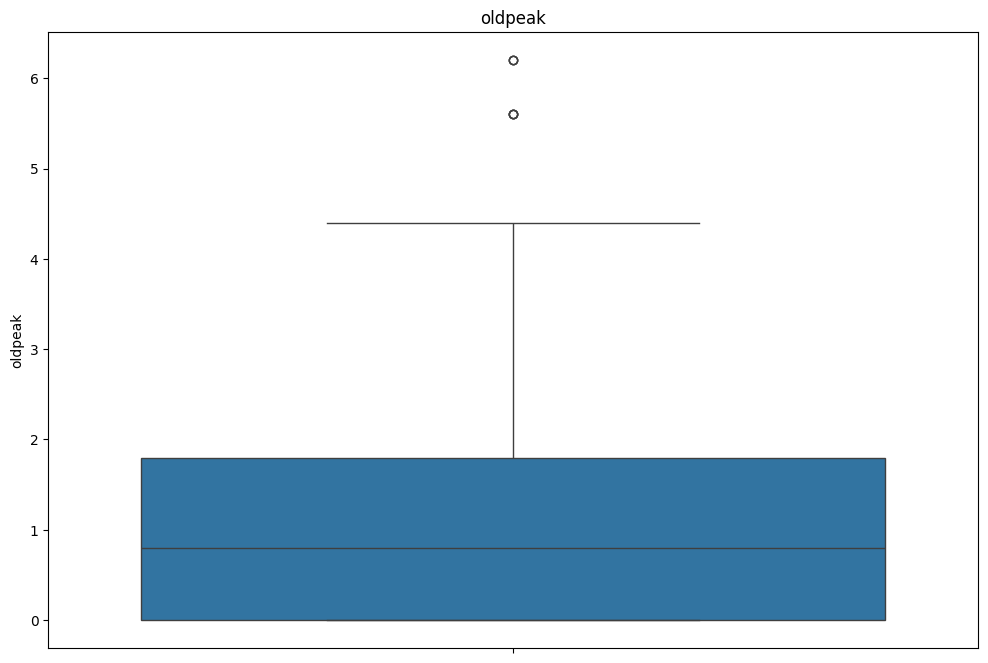

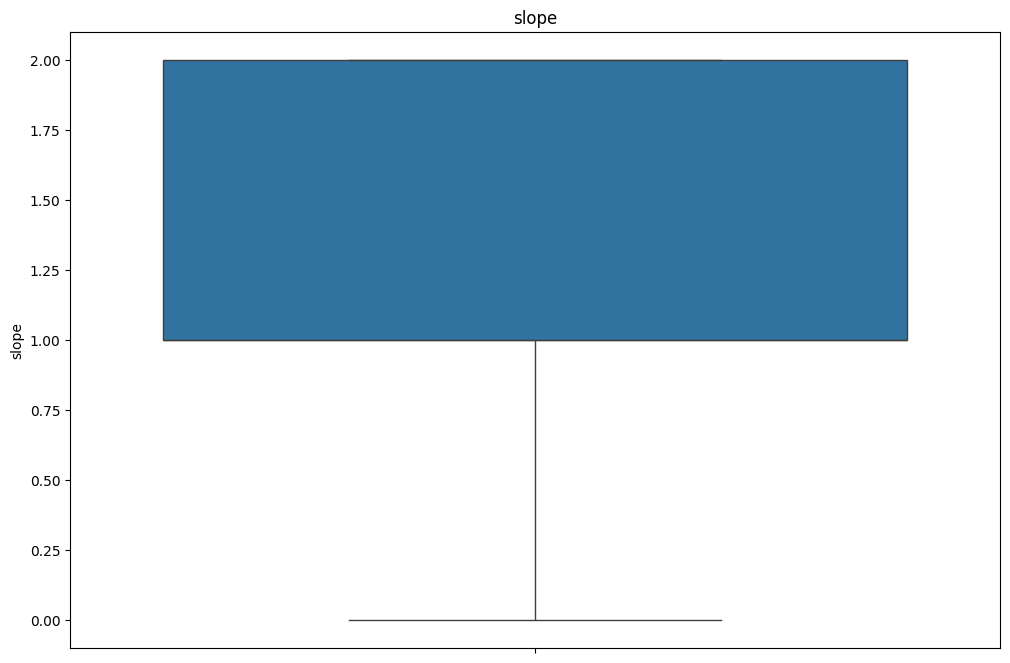

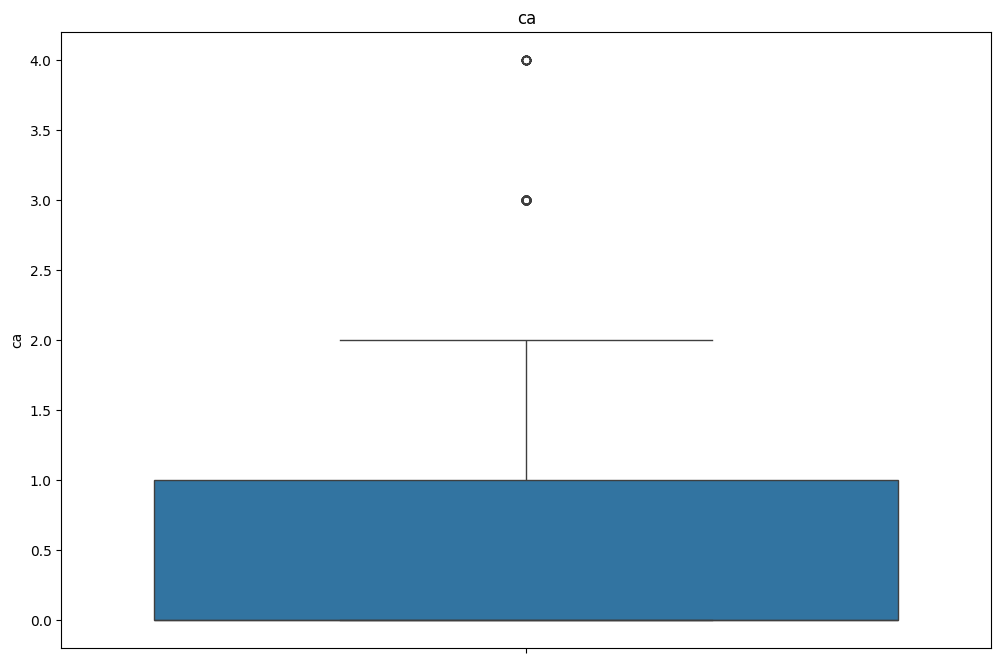

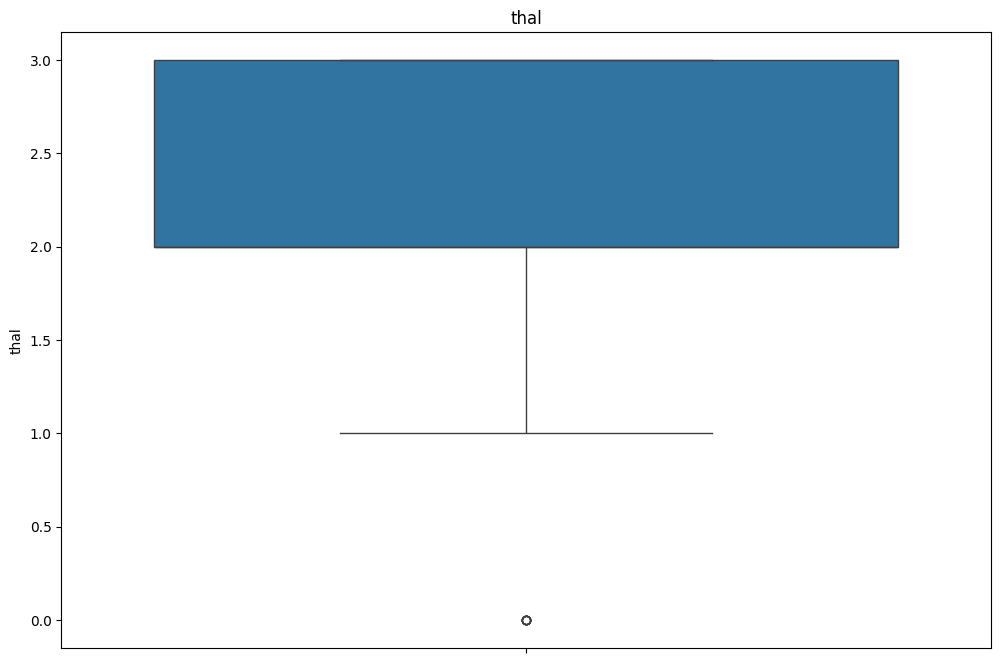

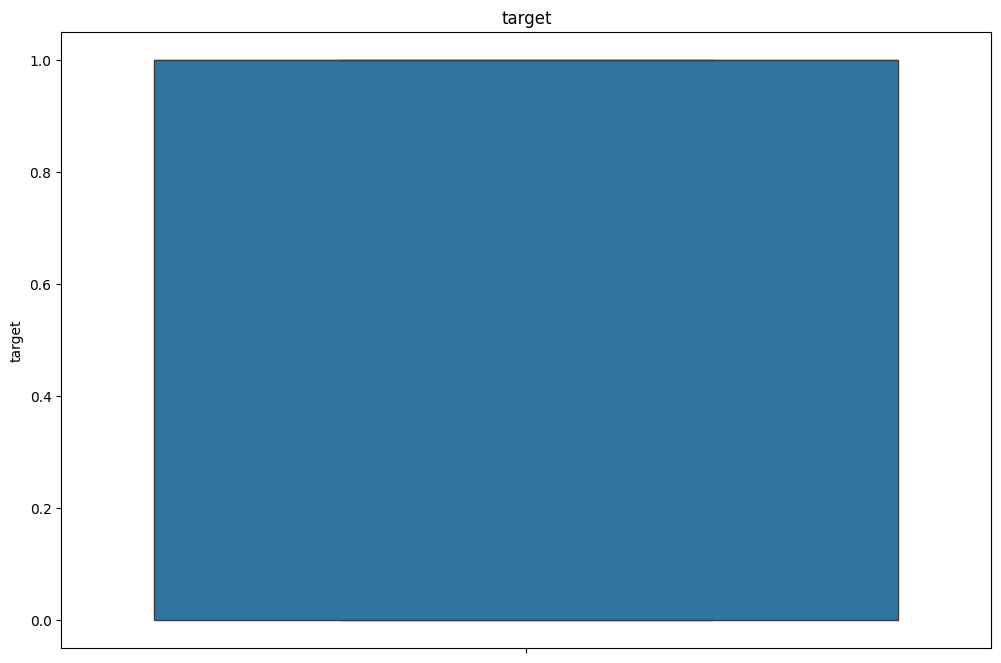

In [266]:
for i in df.columns:
    plt.figure(figsize=(12, 8))
    sns.boxplot(y=df[i])
    plt.title(i)
    plt.show()

In [267]:
for i in df.select_dtypes(include='number').columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR    
    upper_bound = Q3 + 1.5 * IQR
    df[i] = np.where(((df[i] < lower_bound) | (df[i] > upper_bound)), df[i].mean(), df[i])
    

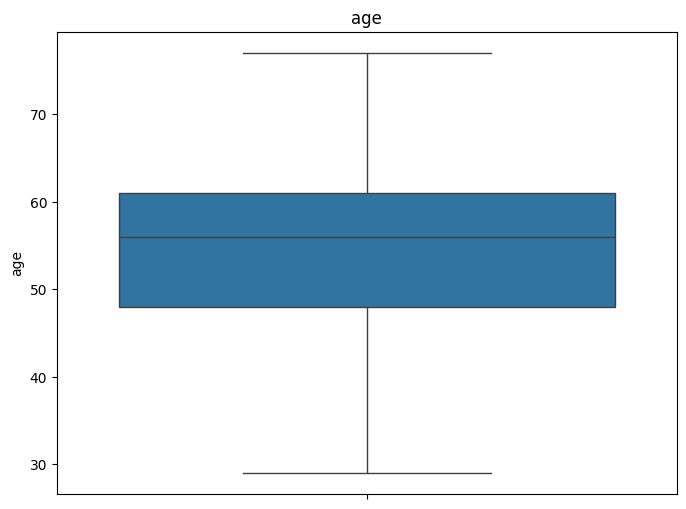

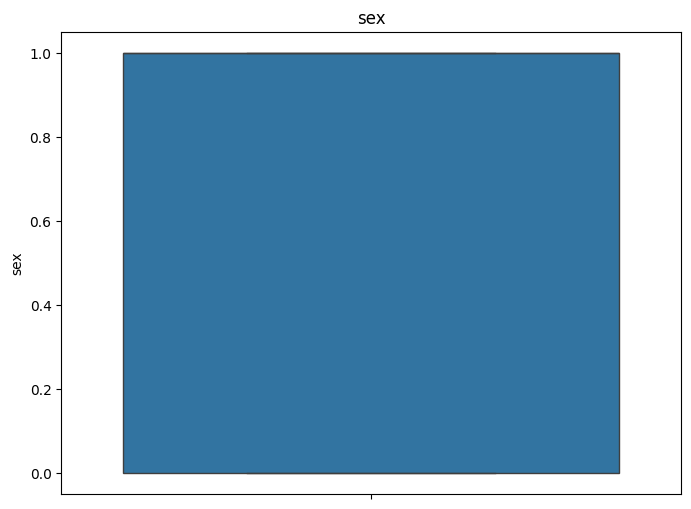

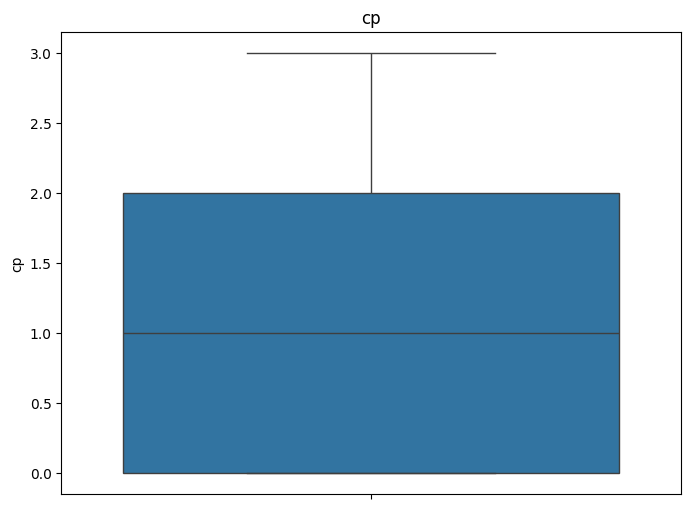

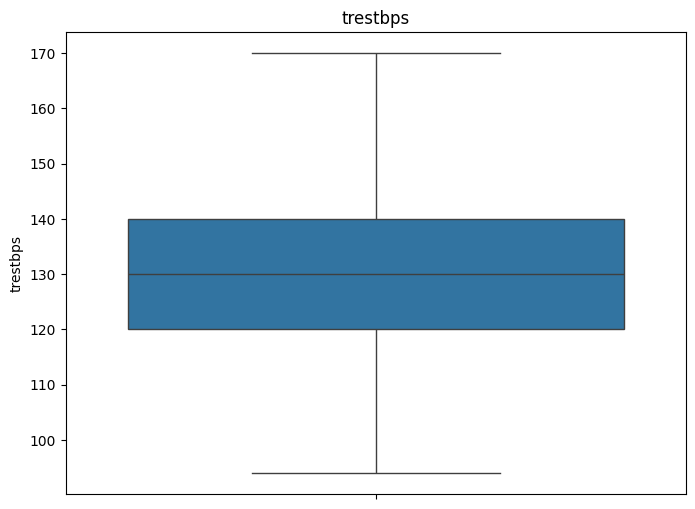

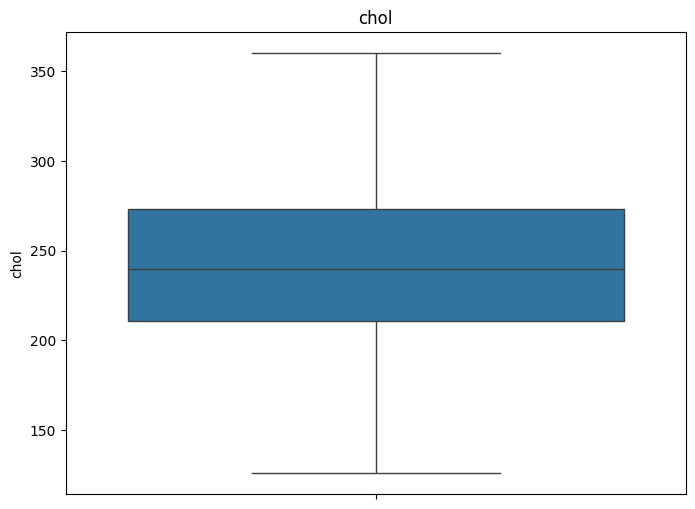

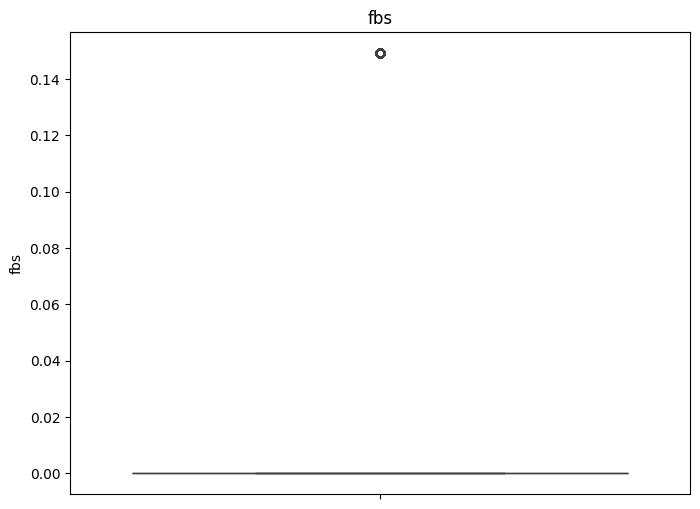

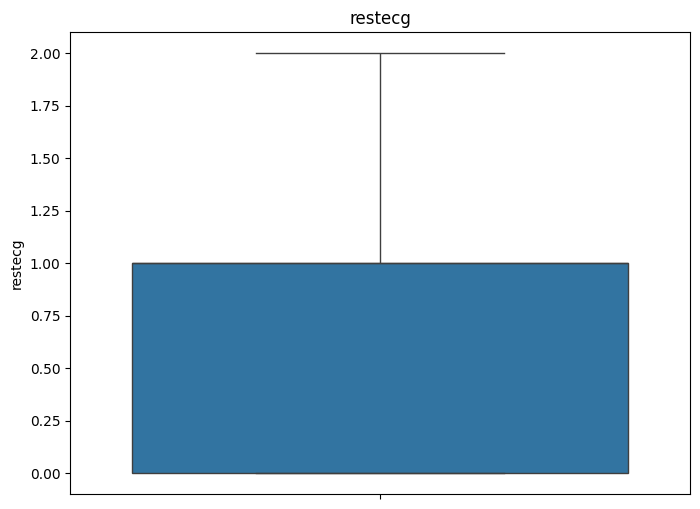

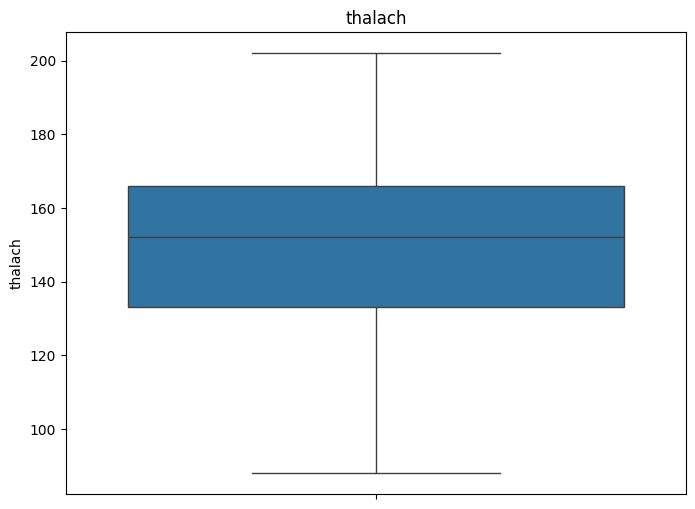

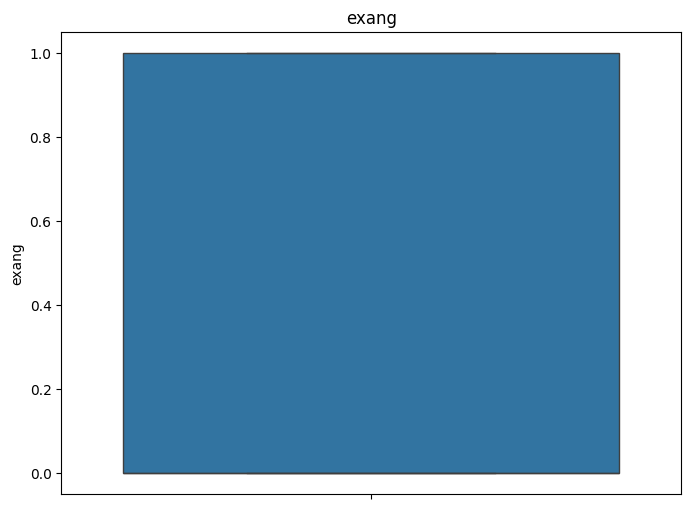

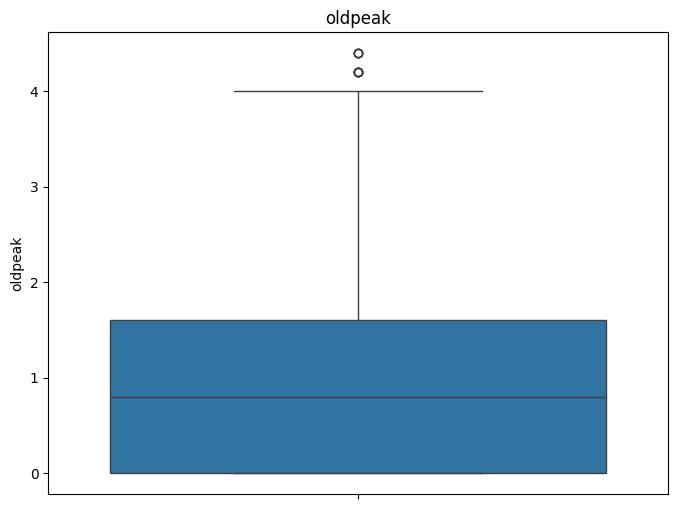

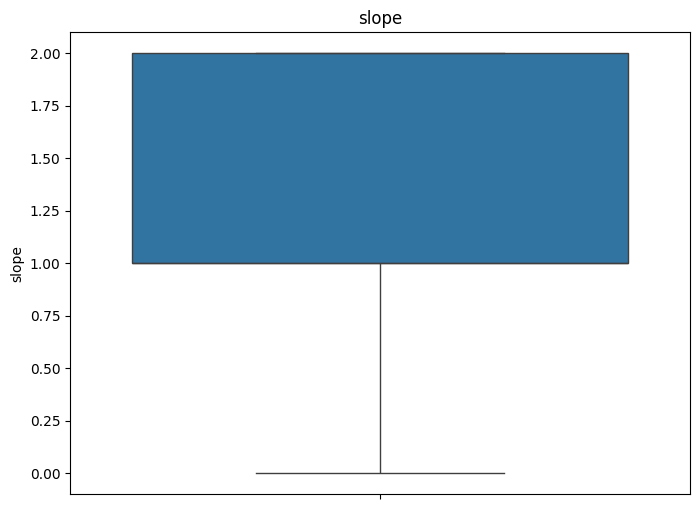

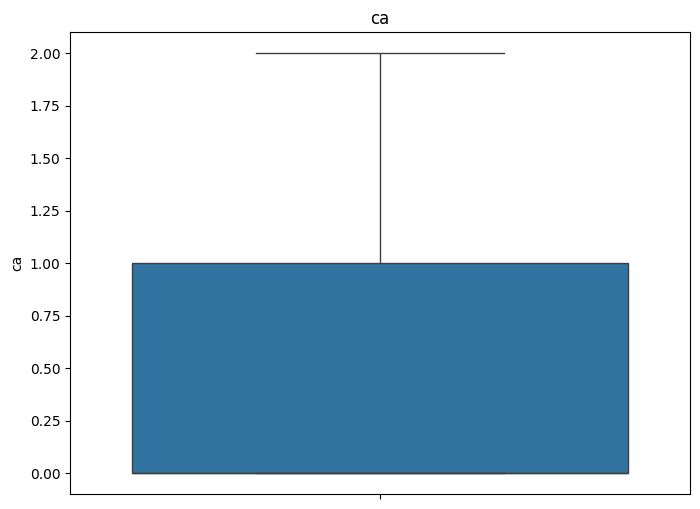

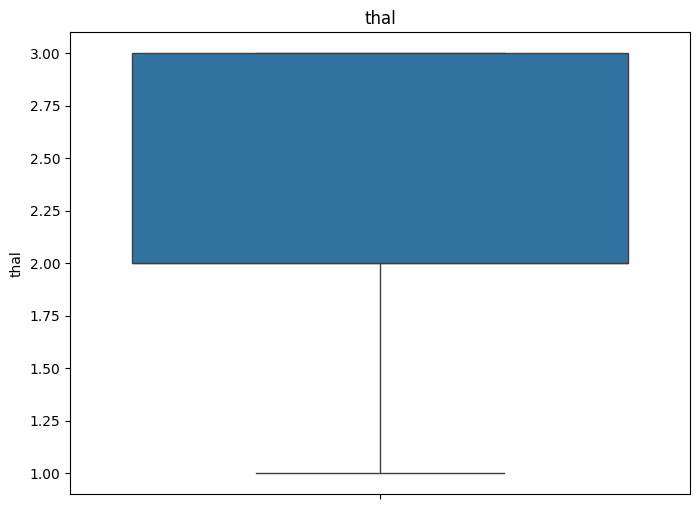

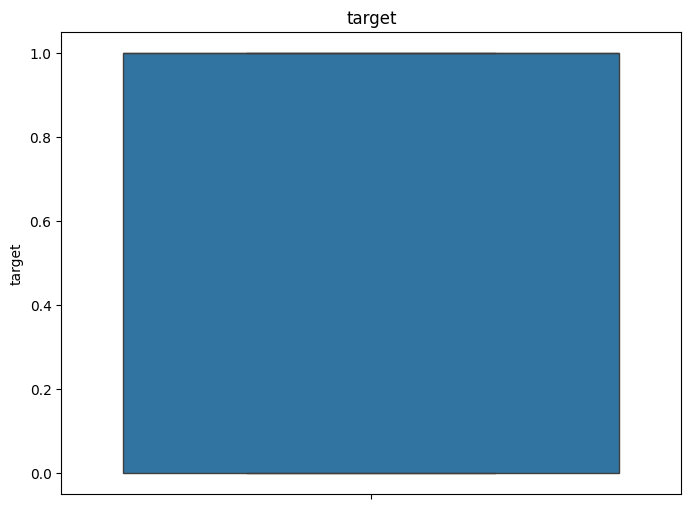

In [268]:
for i in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[i])
    plt.title(i)
    plt.show()

In [269]:
X = df.drop('target', axis=1)
y = df['target']

In [270]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ['age','trestbps','chol','thalach','oldpeak']

# Fit ONCE on all 5 columns together
scaler.fit(X[cols])

# Transform (no loop needed)
X_scaled = X.copy()
X_scaled[cols] = scaler.transform(X[cols])

# Save the scaler
pickle.dump(scaler, open('heart_disease_scaler.pkl', 'wb'))
pickle.dump(cols, open('heart_disease_scaler_columns.pkl', 'wb'))

In [271]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
835,49.0,1.0,2.0,118.000000,149.0,0.000000,0.0,126.0,0.0,0.8,2.0,0.754146,2.0
137,64.0,0.0,0.0,131.611707,325.0,0.000000,1.0,154.0,1.0,0.0,2.0,0.000000,2.0
534,54.0,0.0,2.0,108.000000,267.0,0.000000,0.0,167.0,0.0,0.0,2.0,0.000000,2.0
495,59.0,1.0,0.0,135.000000,234.0,0.000000,1.0,161.0,0.0,0.5,1.0,0.000000,3.0
244,51.0,1.0,2.0,125.000000,245.0,0.149268,0.0,166.0,0.0,2.4,1.0,0.000000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,41.0,1.0,2.0,130.000000,214.0,0.000000,0.0,168.0,0.0,2.0,1.0,0.000000,2.0
71,61.0,1.0,0.0,140.000000,207.0,0.000000,0.0,138.0,1.0,1.9,2.0,1.000000,3.0
106,51.0,1.0,0.0,140.000000,299.0,0.000000,1.0,173.0,1.0,1.6,2.0,0.000000,3.0
270,43.0,1.0,0.0,110.000000,211.0,0.000000,1.0,161.0,0.0,0.0,2.0,0.000000,3.0


In [272]:
X_scaled_train, X_scaled_test, y_scaled_train, y_scaled_test = train_test_split(X_scaled,y_scaled,test_size=0.2,random_state=42)
X_scaled

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.479167,1.0,0.0,0.407895,0.367521,0.000000,1.0,0.701754,0.0,0.227273,2.0,2.000000,3.0
1,0.500000,1.0,0.0,0.605263,0.329060,0.149268,0.0,0.587719,1.0,0.704545,0.0,0.000000,3.0
2,0.854167,1.0,0.0,0.671053,0.205128,0.000000,1.0,0.324561,1.0,0.590909,0.0,0.000000,3.0
3,0.666667,1.0,0.0,0.710526,0.329060,0.000000,1.0,0.640351,0.0,0.000000,2.0,1.000000,3.0
4,0.687500,0.0,0.0,0.578947,0.717949,0.149268,1.0,0.157895,0.0,0.431818,1.0,0.754146,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,0.625000,1.0,1.0,0.605263,0.405983,0.000000,1.0,0.666667,1.0,0.000000,2.0,0.000000,2.0
1021,0.645833,1.0,0.0,0.407895,0.564103,0.000000,0.0,0.464912,1.0,0.636364,1.0,1.000000,3.0
1022,0.375000,1.0,0.0,0.210526,0.636752,0.000000,0.0,0.263158,1.0,0.227273,1.0,1.000000,2.0
1023,0.437500,0.0,0.0,0.210526,0.547009,0.000000,0.0,0.622807,0.0,0.000000,2.0,0.000000,2.0


Model with Scaled data

#LogisticRegression



In [273]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix 

In [274]:
lr_model = LogisticRegression()
lr_model.fit(X_scaled_train, y_scaled_train)
y_pred = lr_model.predict(X_scaled_test)
print(classification_report(y_scaled_test, y_pred))
print(confusion_matrix(y_scaled_test, y_pred))
accuracy = lr_model.score(X_scaled_test, y_scaled_test)
print("Accuracy:", accuracy)


              precision    recall  f1-score   support

         0.0       0.88      0.73      0.80       102
         1.0       0.77      0.90      0.83       103

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205

[[74 28]
 [10 93]]
Accuracy: 0.8146341463414634


Support Vector Machine (SVM)

In [275]:
from sklearn.svm import SVC
svm_model = SVC(probability=True)
svm_model.fit(X_scaled_train, y_scaled_train)
y_pred_svm = svm_model.predict(X_scaled_test)
print(classification_report(y_scaled_test, y_pred_svm))
print(confusion_matrix(y_scaled_test, y_pred_svm))
accuracy_svm = svm_model.score(X_scaled_test, y_scaled_test)
print("Accuracy:", accuracy_svm)

              precision    recall  f1-score   support

         0.0       0.88      0.82      0.85       102
         1.0       0.84      0.89      0.86       103

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205

[[84 18]
 [11 92]]
Accuracy: 0.8585365853658536


K-Nearest Neighbors (KNN)

In [276]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_scaled_train, y_scaled_train)
y_pred_knn = knn_model.predict(X_scaled_test)
print(classification_report(y_scaled_test, y_pred_knn))    
print(confusion_matrix(y_scaled_test, y_pred_knn))
accuracy_knn = knn_model.score(X_scaled_test, y_scaled_test)
print("Accuracy:", accuracy_knn)

              precision    recall  f1-score   support

         0.0       0.86      0.81      0.84       102
         1.0       0.83      0.87      0.85       103

    accuracy                           0.84       205
   macro avg       0.85      0.84      0.84       205
weighted avg       0.85      0.84      0.84       205

[[83 19]
 [13 90]]
Accuracy: 0.8439024390243902


SGD Classifier

In [277]:
from sklearn.linear_model import SGDClassifier

In [278]:
SGD_model = SGDClassifier()
SGD_model.fit(X_scaled_train, y_scaled_train)
y_pred_sgd = SGD_model.predict(X_scaled_test)
print(classification_report(y_scaled_test, y_pred_sgd))
print(confusion_matrix(y_scaled_test, y_pred_sgd))
accuracy_sgd = SGD_model.score(X_scaled_test, y_scaled_test)
print("Accuracy:", accuracy_sgd)

              precision    recall  f1-score   support

         0.0       0.89      0.73      0.80       102
         1.0       0.77      0.91      0.84       103

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205

[[74 28]
 [ 9 94]]
Accuracy: 0.8195121951219512


Models without scaled data 

Random Forest

In [279]:
from sklearn.ensemble import RandomForestClassifier

In [280]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
accuracy_rf = model_rf.score(X_test, y_test)
print("Accuracy:", accuracy_rf) 

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       102
         1.0       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

[[102   0]
 [  3 100]]
Accuracy: 0.9853658536585366


Decision Tree

In [281]:
from sklearn.tree import DecisionTreeClassifier
model_dtc = DecisionTreeClassifier(random_state=42)
model_dtc.fit(X_train, y_train)
y_pred_dtc = model_dtc.predict(X_test)
print(classification_report(y_test, y_pred_dtc))
print(confusion_matrix(y_test, y_pred_dtc))
accuracy_dtc = model_dtc.score(X_test, y_test)
print("Accuracy:", accuracy_dtc)

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       102
         1.0       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

[[102   0]
 [  3 100]]
Accuracy: 0.9853658536585366


In [282]:
# import pickle
# pickle.dump(model_rf, open('heart_disease_model.pkl', 'wb'))
# pickle.dump(X.columns.to_list(), open('heart_disease_columns.pkl', 'wb'))

In [283]:
import pickle
pickle.dump(svm_model, open('heart_disease_model.pkl', 'wb'))
pickle.dump(X_scaled.columns.tolist(), open('heart_disease_columns.pkl', 'wb'))